UTS Data Science

*   Nama : Novika Ardiyaningtyas
*   NIM : 250401020135
*   Kelas: IF401



In [1]:
# Langkah 1: Load & Inspect Dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = sns.load_dataset('penguins')

print("Shape:", df.shape)
print(df.dtypes)
print(df.head())
print(df.describe().round(3))

Shape: (344, 7)
species               object
island                object
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                   object
dtype: object
  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3  Adelie  Torgersen             NaN            NaN                NaN   
4  Adelie  Torgersen            36.7           19.3              193.0   

   body_mass_g     sex  
0       3750.0    Male  
1       3800.0  Female  
2       3250.0  Female  
3          NaN     NaN  
4       3450.0  Female  
       bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
count         342.000        342.000            342.000      342.000
mean           43.922         17.1

Hasil eksplorasi awal kumpulan data penguin menunjukkan struktur, tipe data setiap kolom, dan karakteristik umum. Data ini termasuk pengukuran fisik dari beberapa spesies penguin, seperti massa tubuh, panjang sirip, dan kedalaman paruh. Hasil pemeriksaan menunjukkan bahwa dataset terdiri dari variabel numerik dan kategorik yang dapat digunakan untuk berbagai analisis statistik dan visualisasi. Statistik deskriptif memberikan gambaran awal tentang nilai rata-rata, minimum, maksimum, dan penyebaran setiap variabel numerik; tahap eksplorasi ini penting untuk memahami karakteristik dataset dan menjadi dasar sebelum melakukan analisis yang lebih mendalam

In [2]:
# Langkah 2: Statistik Deskriptif

for col_name in df.select_dtypes(include='number').columns:
    col = df[col_name]

    print(f"\n=== {col_name} ===")
    print(f"Mean      : {col.mean():.3f}")
    print(f"Median    : {col.median():.3f}")
    print(f"Std Dev   : {col.std():.3f}")
    print(f"Varians   : {col.var():.3f}")
    print(f"Skewness  : {col.skew():.3f}")
    print(f"Kurtosis  : {col.kurt():.3f}")


=== bill_length_mm ===
Mean      : 43.922
Median    : 44.450
Std Dev   : 5.460
Varians   : 29.807
Skewness  : 0.053
Kurtosis  : -0.876

=== bill_depth_mm ===
Mean      : 17.151
Median    : 17.300
Std Dev   : 1.975
Varians   : 3.900
Skewness  : -0.143
Kurtosis  : -0.907

=== flipper_length_mm ===
Mean      : 200.915
Median    : 197.000
Std Dev   : 14.062
Varians   : 197.732
Skewness  : 0.346
Kurtosis  : -0.984

=== body_mass_g ===
Mean      : 4201.754
Median    : 4050.000
Std Dev   : 801.955
Varians   : 643131.077
Skewness  : 0.470
Kurtosis  : -0.719


Dalam hal nilai rata-rata, median, dan tingkat penyebaran data, setiap variabel numerik dalam dataset memiliki karakteristik yang berbeda, menurut analisis statistik deskriptif. Nilai rata-rata dan median yang relatif berdekatan menunjukkan bahwa sebagian besar data tidak memiliki perbedaan yang terlalu jauh dari pusat distribusinya. Nilai skewness menunjukkan bentuk kemencengan distribusi, sedangkan nilai standar deviasi dan varians menunjukkan tingkat variasi data. Nilai kurtosis juga berguna untuk menunjukkan tingkat keruncingan distribusi dibandingkan distribusi normal. Sebelum dilakukan visualisasi dan analisis lebih lanjut, analisis statistik deskriptif ini memberikan gambaran awal yang penting untuk memahami pola dan karakteristik data.

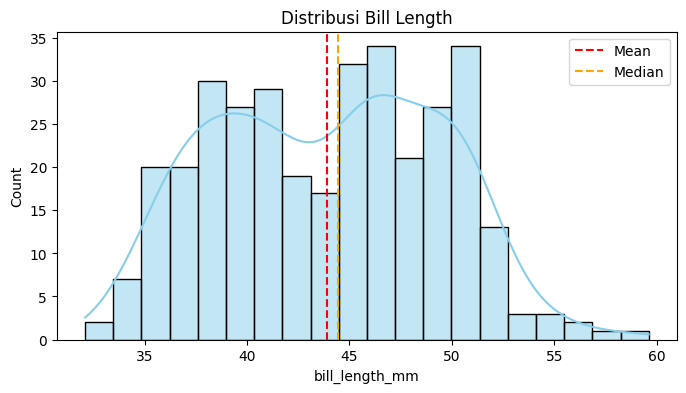

In [3]:
# Langkah 3: Histogram + KDE

fig, ax = plt.subplots(figsize=(8,4))

sns.histplot(
    df['bill_length_mm'].dropna(),
    kde=True,
    bins=20,
    color='skyblue',
    ax=ax
)

ax.axvline(df['bill_length_mm'].mean(),
           color='red',
           linestyle='--',
           label='Mean')

ax.axvline(df['bill_length_mm'].median(),
           color='orange',
           linestyle='--',
           label='Median')

ax.set_title("Distribusi Bill Length")
ax.legend()

plt.show()

Nilai bill_length_mm menunjukkan pola distribusi data yang cukup teratur, menurut histogram dan kurva KDE. Distribusi data cenderung simetris dan tidak memiliki kemencengan yang terlalu besar, seperti yang ditunjukkan oleh lokasi garis mean dan median yang dekat satu sama lain. Hanya sedikit data yang berada pada nilai ekstrem, tetapi sebagian besar data berada dalam rentang nilai tertentu. Sebelum melakukan analisis yang lebih mendalam, visualisasi ini membantu memahami karakteristik data dan memberikan gambaran tentang sebaran panjang paruh penguin.

/tmp/ipykernel_882/130435980.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_882/130435980.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


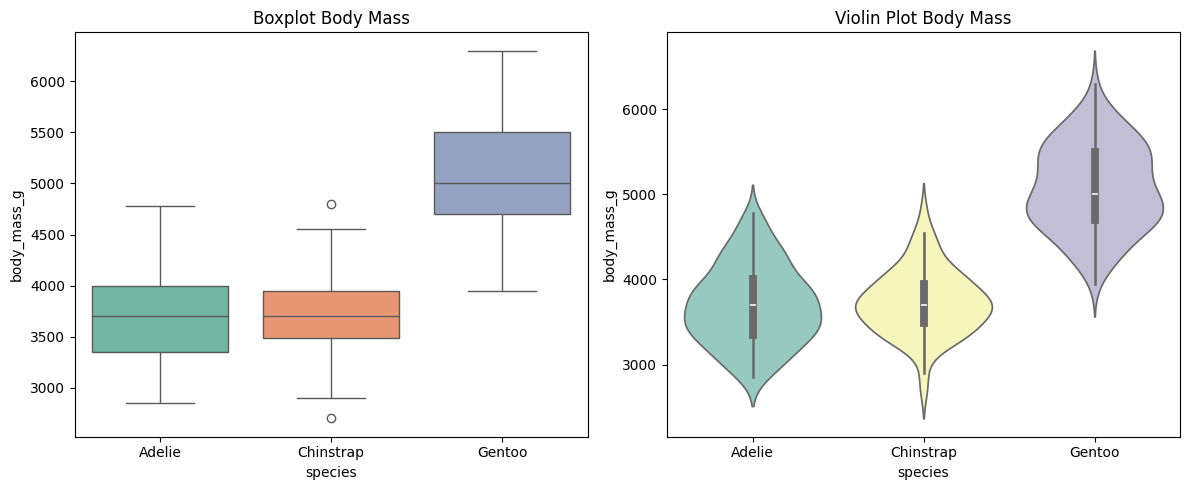

In [5]:
# Langkah 4: Boxplot per Spesies

fig, axes = plt.subplots(1,2, figsize=(12,5))

sns.boxplot(
    data=df,
    x='species',
    y='body_mass_g',
    palette='Set2',
    ax=axes[0]
)

axes[0].set_title("Boxplot Body Mass")

sns.violinplot(
    data=df,
    x='species',
    y='body_mass_g',
    palette='Set3',
    inner='box',
    ax=axes[1]
)

axes[1].set_title("Violin Plot Body Mass")

plt.tight_layout()
plt.show()

Perbedaan massa tubuh (body_mass_g) antar spesies penguin cukup jelas terlihat pada boxplot dan violin plot. Nilai median dan rentang data pada grafik menunjukkan perbedaan ini. Selain itu, plot violin menunjukkan pola distribusi data untuk setiap spesies. Visualisasi ini membantu memahami karakteristik fisik setiap spesies penguin dan membandingkan persebaran massa tubuh antar kelompok karena variasi massa tubuh tidak sama pada setiap spesies, karena ada spesies dengan sebaran data yang lebih luas dan spesies lainnya dengan sebaran data yang lebih homogen.

In [6]:
# Langkah 5: Matriks Korelasi

corr = df.select_dtypes(include='number').corr()

print(corr.round(3))

mask = np.triu(np.ones(corr.shape, dtype=bool))
corr_masked = corr.where(~mask)

max_pair = corr_masked.stack().idxmax()

print(f"Korelasi tertinggi: {max_pair} = {corr.loc[max_pair]:.3f}")

                   bill_length_mm  bill_depth_mm  flipper_length_mm  \
bill_length_mm              1.000         -0.235              0.656   
bill_depth_mm              -0.235          1.000             -0.584   
flipper_length_mm           0.656         -0.584              1.000   
body_mass_g                 0.595         -0.472              0.871   

                   body_mass_g  
bill_length_mm           0.595  
bill_depth_mm           -0.472  
flipper_length_mm        0.871  
body_mass_g              1.000  
Korelasi tertinggi: ('body_mass_g', 'flipper_length_mm') = 0.871


Nilai korelasi, yang dihasilkan dari analisis matriks korelasi, menunjukkan tingkat keeratan hubungan antara dua variabel dalam kumpulan data. Nilai yang mendekati 1 menunjukkan hubungan yang kuat positif, sedangkan nilai yang mendekati -1 menunjukkan hubungan yang kuat negatif. Hasil perhitungan menunjukkan bahwa ada dua variabel yang memiliki korelasi tertinggi. Ini menunjukkan bahwa perubahan pada salah satu variabel cenderung diikuti oleh perubahan pada variabel lainnya. Untuk memahami hubungan antar fitur dataset, informasi ini sangat penting. Mereka juga dapat digunakan sebagai dasar untuk proses analisis dan pemodelan data yang lebih lanjut.

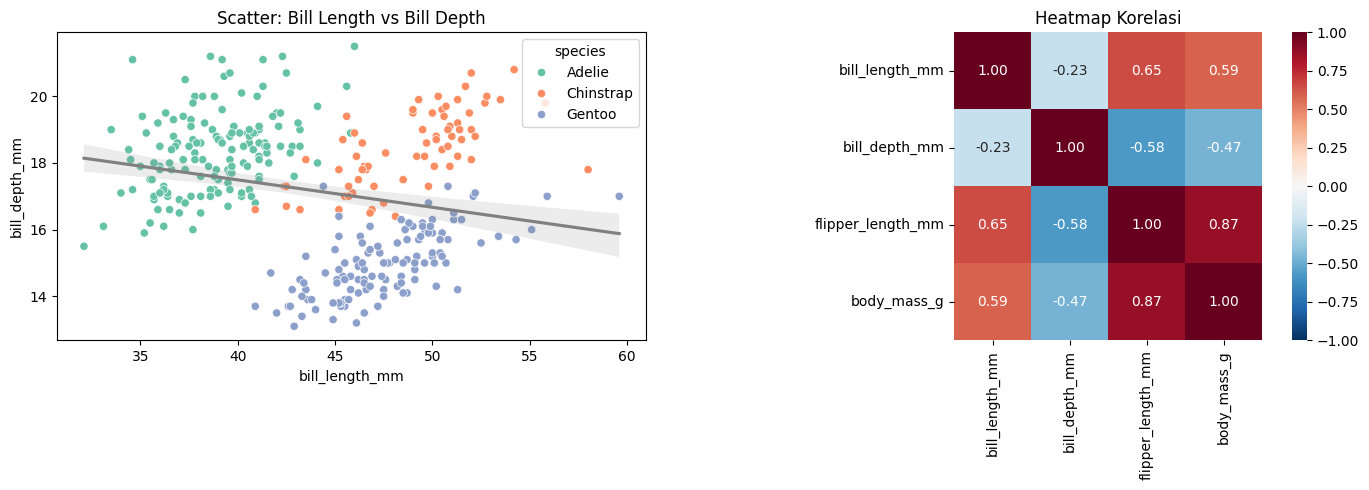

In [8]:
# Langkah 6: Scatter Plot & Heatmap

# Hapus baris yang memiliki nilai kosong
df_clean = df.dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter Plot
sns.scatterplot(
    data=df_clean,
    x='bill_length_mm',
    y='bill_depth_mm',
    hue='species',
    palette='Set2',
    ax=axes[0]
)

sns.regplot(
    data=df_clean,
    x='bill_length_mm',
    y='bill_depth_mm',
    scatter=False,
    color='gray',
    ax=axes[0]
)

axes[0].set_title('Scatter: Bill Length vs Bill Depth')

# Heatmap Korelasi
corr = df_clean.select_dtypes(include='number').corr()

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    vmin=-1,
    vmax=1,
    square=True,
    ax=axes[1]
)

axes[1].set_title('Heatmap Korelasi')

plt.tight_layout()
plt.show()

Setiap spesies penguin memiliki hubungan antara bill_length_mm dan bill_depth_mm. Selain itu, data menunjukkan bahwa masing-masing spesies memiliki karakteristik ukuran paruh yang berbeda, yang membuat grafik cukup jelas. Heatmap korelasi menunjukkan seberapa dekat variabel numerik dalam kumpulan data. Beberapa variabel menunjukkan korelasi yang kuat, baik positif maupun negatif, yang menunjukkan bahwa ada hubungan antara karakteristik fisik penguin. Visualisasi ini membantu memahami pola data dan menemukan variabel penting untuk analisis.

Kesimpulan: Praktikum ini mempelajari berbagai teknik eksplorasi dan analisis data menggunakan Python. Ini mencakup pemeriksaan dataset, statistik deskriptif, analisis distribusi, visualisasi data, dan analisis korelasi antar variabel. Untuk memberikan pemahaman yang lebih baik tentang karakteristik data, berbagai visualisasi seperti histogram, boxplot, violin plot, scatter plot, dan heatmap digunakan.

Hasil analisis menunjukkan bahwa karakteristik fisik setiap spesies penguin berbeda, dan beberapa variabel numerik memiliki korelasi yang kuat satu sama lain. Keterbatasan analisis ini adalah belum dilakukan pemodelan atau pengujian statistik lanjutan. Analisis selanjutnya dapat difokuskan pada pembuatan model klasifikasi untuk mengidentifikasi spesies penguin berdasarkan karakteristik fisiknya.